<center>
    <h1>Employee Attrition Prediction</h1>
</center>

# 1. Importing necessary libraries 

In [560]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score, f1_score, 
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay, precision_score, recall_score)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, BaggingClassifier
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, TransformerMixin
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from scipy.stats import randint, uniform

import warnings
warnings.filterwarnings('ignore')

# 2. Loading the dataset and initial exploration

In [561]:
train_df = pd.read_csv('Train_Dataset.csv')
test_df = pd.read_csv('Test_Dataset.csv')

print("Train Data Shape:", train_df.shape)
print("Test Data Shape:", test_df.shape)
print("\nTrain Data Sample:")
display(train_df.head())
print("\nTest Data Sample:")
display(test_df.head())

Train Data Shape: (7810, 22)
Test Data Shape: (2630, 21)

Train Data Sample:


,EmployeeID,Attrition,Age,TravelProfile,Department,HomeToWork,EducationField,Gender,HourlnWeek,Involvement,...,JobSatisfaction,ESOPs,NumCompaniesWorked,OverTime,SalaryHikelastYear,WorkExperience,LastPromotion,CurrentProfile,MaritalStatus,MonthlyIncome
0,5110001.0,0.0,35.0,Rarely,Analytics,5.0,CA,Male,69.0,1.0,...,1.0,1.0,1.0,1.0,20.0,7.0,2.0,NaN,M,18932.0
1,5110002.0,1.0,32.0,Yes,Sales,5.0,Statistics,Female,62.0,4.0,...,2.0,0.0,8.0,0.0,20.0,4.0,1.0,NaN,Single,18785.0
2,5110003.0,0.0,31.0,Rarely,Analytics,5.0,Statistics,F,45.0,5.0,...,2.0,1.0,3.0,0.0,26.0,12.0,1.0,3.0,Single,22091.0
3,5110004.0,0.0,34.0,Yes,Sales,10.0,Statistics,Female,32.0,3.0,...,4.0,1.0,1.0,0.0,23.0,5.0,1.0,3.0,Divorsed,20302.0
4,5110005.0,0.0,37.0,No,Analytics,27.0,Statistics,Female,49.0,3.0,...,4.0,1.0,8.0,0.0,21.0,12.0,1.0,9.0,Divorsed,21674.0



Test Data Sample:


,EmployeeID,Age,TravelProfile,Department,HomeToWork,EducationField,Gender,HourlnWeek,Involvement,WorkLifeBalance,...,JobSatisfaction,ESOPs,NumCompaniesWorked,OverTime,SalaryHikelastYear,WorkExperience,LastPromotion,CurrentProfile,MaritalStatus,MonthlyIncome
0,6110001,18.0,No,NaN,9.0,CA,Male,80.0,3,2,...,3,1,1,0,17.0,0.0,0.0,0.0,Single,16904.0
1,6110002,20.0,Rarely,Analytics,28.0,Statistics,Female,59.0,1,3,...,1,1,2,1,18.0,2.0,1.0,NaN,Single,18994.0
2,6110003,50.0,Rarely,Analytics,19.0,CA,Female,76.0,3,3,...,5,0,5,1,22.0,18.0,3.0,3.0,M,18587.0
3,6110004,32.0,Rarely,Sales,23.0,Statistics,Female,73.0,5,2,...,3,0,4,1,17.0,5.0,3.0,3.0,Married,20559.0
4,6110005,39.0,Rarely,Analytics,7.0,CA,Male,42.0,4,1,...,5,1,4,0,20.0,9.0,1.0,7.0,Married,24991.0


In [562]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7810 entries, 0 to 7809
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   EmployeeID          5180 non-null   float64
 1   Attrition           5180 non-null   float64
 2   Age                 4864 non-null   float64
 3   TravelProfile       5180 non-null   object 
 4   Department          5056 non-null   object 
 5   HomeToWork          4925 non-null   float64
 6   EducationField      5180 non-null   object 
 7   Gender              5134 non-null   object 
 8   HourlnWeek          4893 non-null   float64
 9   Involvement         5180 non-null   float64
 10  WorkLifeBalance     5180 non-null   float64
 11  Designation         5142 non-null   object 
 12  JobSatisfaction     5180 non-null   float64
 13  ESOPs               5180 non-null   float64
 14  NumCompaniesWorked  5180 non-null   float64
 15  OverTime            5180 non-null   float64
 16  Salary

In [563]:
train_df.tail()

,EmployeeID,Attrition,Age,TravelProfile,Department,HomeToWork,EducationField,Gender,HourlnWeek,Involvement,...,JobSatisfaction,ESOPs,NumCompaniesWorked,OverTime,SalaryHikelastYear,WorkExperience,LastPromotion,CurrentProfile,MaritalStatus,MonthlyIncome
7805,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7806,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7807,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7808,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7809,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [564]:
train_df = train_df.iloc[:5180, :]

In [565]:
train_df.tail()

,EmployeeID,Attrition,Age,TravelProfile,Department,HomeToWork,EducationField,Gender,HourlnWeek,Involvement,...,JobSatisfaction,ESOPs,NumCompaniesWorked,OverTime,SalaryHikelastYear,WorkExperience,LastPromotion,CurrentProfile,MaritalStatus,MonthlyIncome
5175,5115176.0,0.0,36.0,Rarely,Analytics,13.0,CA,F,53.0,3.0,...,3.0,0.0,4.0,1.0,22.0,11.0,1.0,5.0,Single,22142.0
5176,5115177.0,0.0,NaN,Rarely,Marketing,9.0,CA,Female,66.0,1.0,...,4.0,1.0,9.0,0.0,23.0,8.0,0.0,2.0,Single,17109.0
5177,5115178.0,0.0,29.0,Rarely,Analytics,NaN,CA,Female,62.0,4.0,...,1.0,1.0,6.0,0.0,19.0,8.0,0.0,3.0,M,17532.0
5178,5115179.0,0.0,26.0,Rarely,Marketing,26.0,Statistics,Female,61.0,3.0,...,3.0,0.0,1.0,0.0,28.0,8.0,5.0,7.0,Divorsed,17942.0
5179,5115180.0,1.0,NaN,Yes,Sales,13.0,Statistics,Male,74.0,4.0,...,5.0,1.0,1.0,0.0,23.0,1.0,0.0,0.0,Divorsed,17033.0


In [566]:
train_df.describe()

,EmployeeID,Attrition,Age,HomeToWork,HourlnWeek,Involvement,WorkLifeBalance,JobSatisfaction,ESOPs,NumCompaniesWorked,OverTime,SalaryHikelastYear,WorkExperience,LastPromotion,CurrentProfile,MonthlyIncome
count,5.180000e+03,5180.000000,4864.000000,4925.000000,4893.000000,5180.000000,5180.000000,5180.000000,5180.000000,5180.000000,5180.000000,5011.000000,4993.000000,5110.000000,4869.000000,5087.000000
mean,5.112590e+06,0.278958,37.108553,11.107411,57.979767,3.226641,3.012741,3.144402,0.490541,3.157336,0.313514,20.649371,11.165832,2.552838,4.385295,21692.296442
std,1.495482e+03,0.448530,9.248647,8.455577,12.996674,0.872431,1.410602,1.342776,0.499959,2.606036,0.463966,3.706469,7.797783,3.234467,3.617643,4770.637922
min,5.110001e+06,0.000000,18.000000,1.000000,10.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,16.000000,0.000000,0.000000,0.000000,1000.000000
25%,5.111296e+06,0.000000,30.000000,5.000000,49.000000,3.000000,2.000000,2.000000,0.000000,1.000000,0.000000,18.000000,6.000000,1.000000,2.000000,18362.000000
50%,5.112590e+06,0.000000,36.000000,9.000000,59.000000,3.000000,3.000000,3.000000,0.000000,2.000000,0.000000,20.000000,9.000000,1.000000,3.000000,20160.000000
75%,5.113885e+06,1.000000,43.000000,16.000000,67.000000,4.000000,4.000000,4.000000,1.000000,5.000000,1.000000,23.000000,15.000000,3.000000,7.000000,23443.500000
max,5.115180e+06,1.000000,61.000000,121.000000,99.000000,5.000000,5.000000,5.000000,1.000000,21.000000,1.000000,31.000000,41.000000,16.000000,18.000000,95000.000000


In [567]:
train_df.duplicated().sum()

np.int64(0)

In [568]:
is_null = train_df.isna().sum()
is_null[is_null > 0]

Age                   316
Department            124
HomeToWork            255
Gender                 46
HourlnWeek            287
Designation            38
SalaryHikelastYear    169
WorkExperience        187
LastPromotion          70
CurrentProfile        311
MonthlyIncome          93
dtype: int64

In [569]:
train_df.drop(columns='EmployeeID', inplace=True)

In [570]:
X = train_df.drop('Attrition', axis=1)
y = train_df['Attrition']

cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(exclude=['object']).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42, stratify=y)

In [571]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (4662, 20)
y_train shape: (4662,)
X_test shape: (518, 20)
y_test shape: (518,)


In [572]:
print("Categorical columns:\n", cat_cols)
print("\nNumerical columns:\n", num_cols)

Categorical columns:
 ['TravelProfile', 'Department', 'EducationField', 'Gender', 'Designation', 'MaritalStatus']

Numerical columns:
 ['Age', 'HomeToWork', 'HourlnWeek', 'Involvement', 'WorkLifeBalance', 'JobSatisfaction', 'ESOPs', 'NumCompaniesWorked', 'OverTime', 'SalaryHikelastYear', 'WorkExperience', 'LastPromotion', 'CurrentProfile', 'MonthlyIncome']


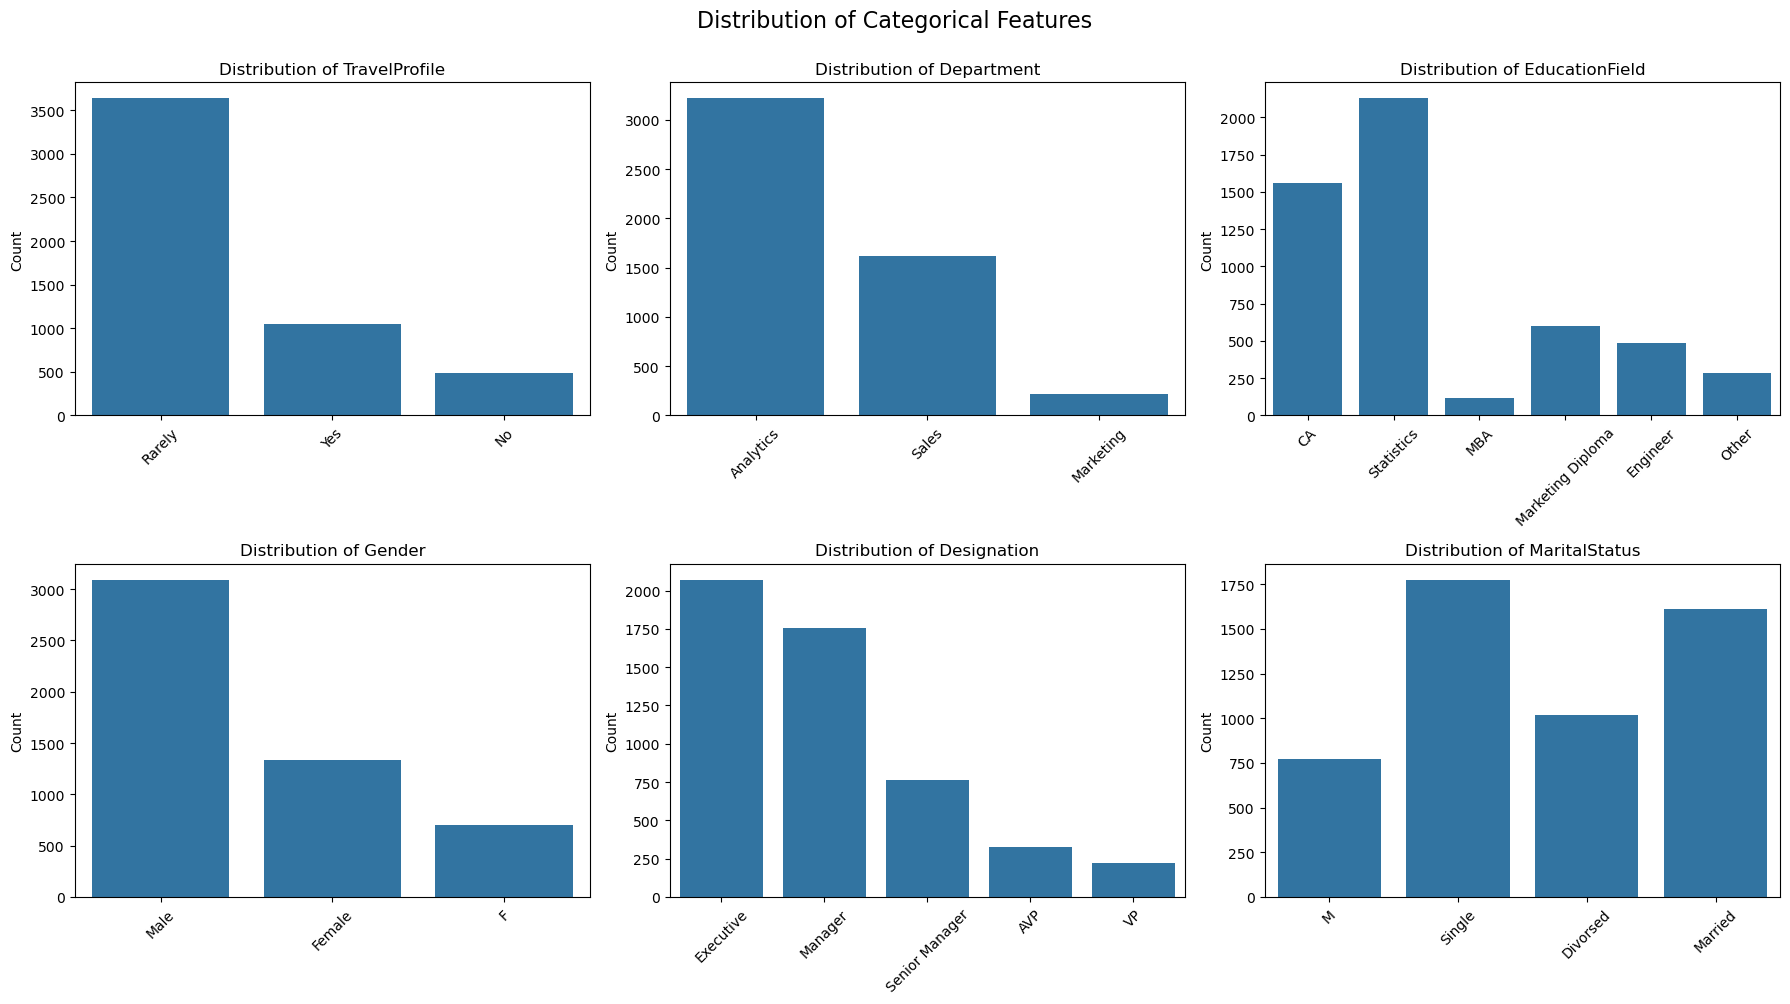

In [573]:
row = np.ceil(len(cat_cols) / 3).astype(int)
col = 3

fig, axes = plt.subplots(row, col, figsize=(18, 10))
fig.suptitle('Distribution of Categorical Features', fontsize=16, y=1)
axes = axes.flatten()

for i, col_name in enumerate(cat_cols):
    ax = axes[i]
    sns.countplot(x=col_name, data=train_df, ax=ax)
    ax.set_title(f'Distribution of {col_name}')
    ax.tick_params(axis='x', rotation=45)
    ax.set_xlabel('')
    ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

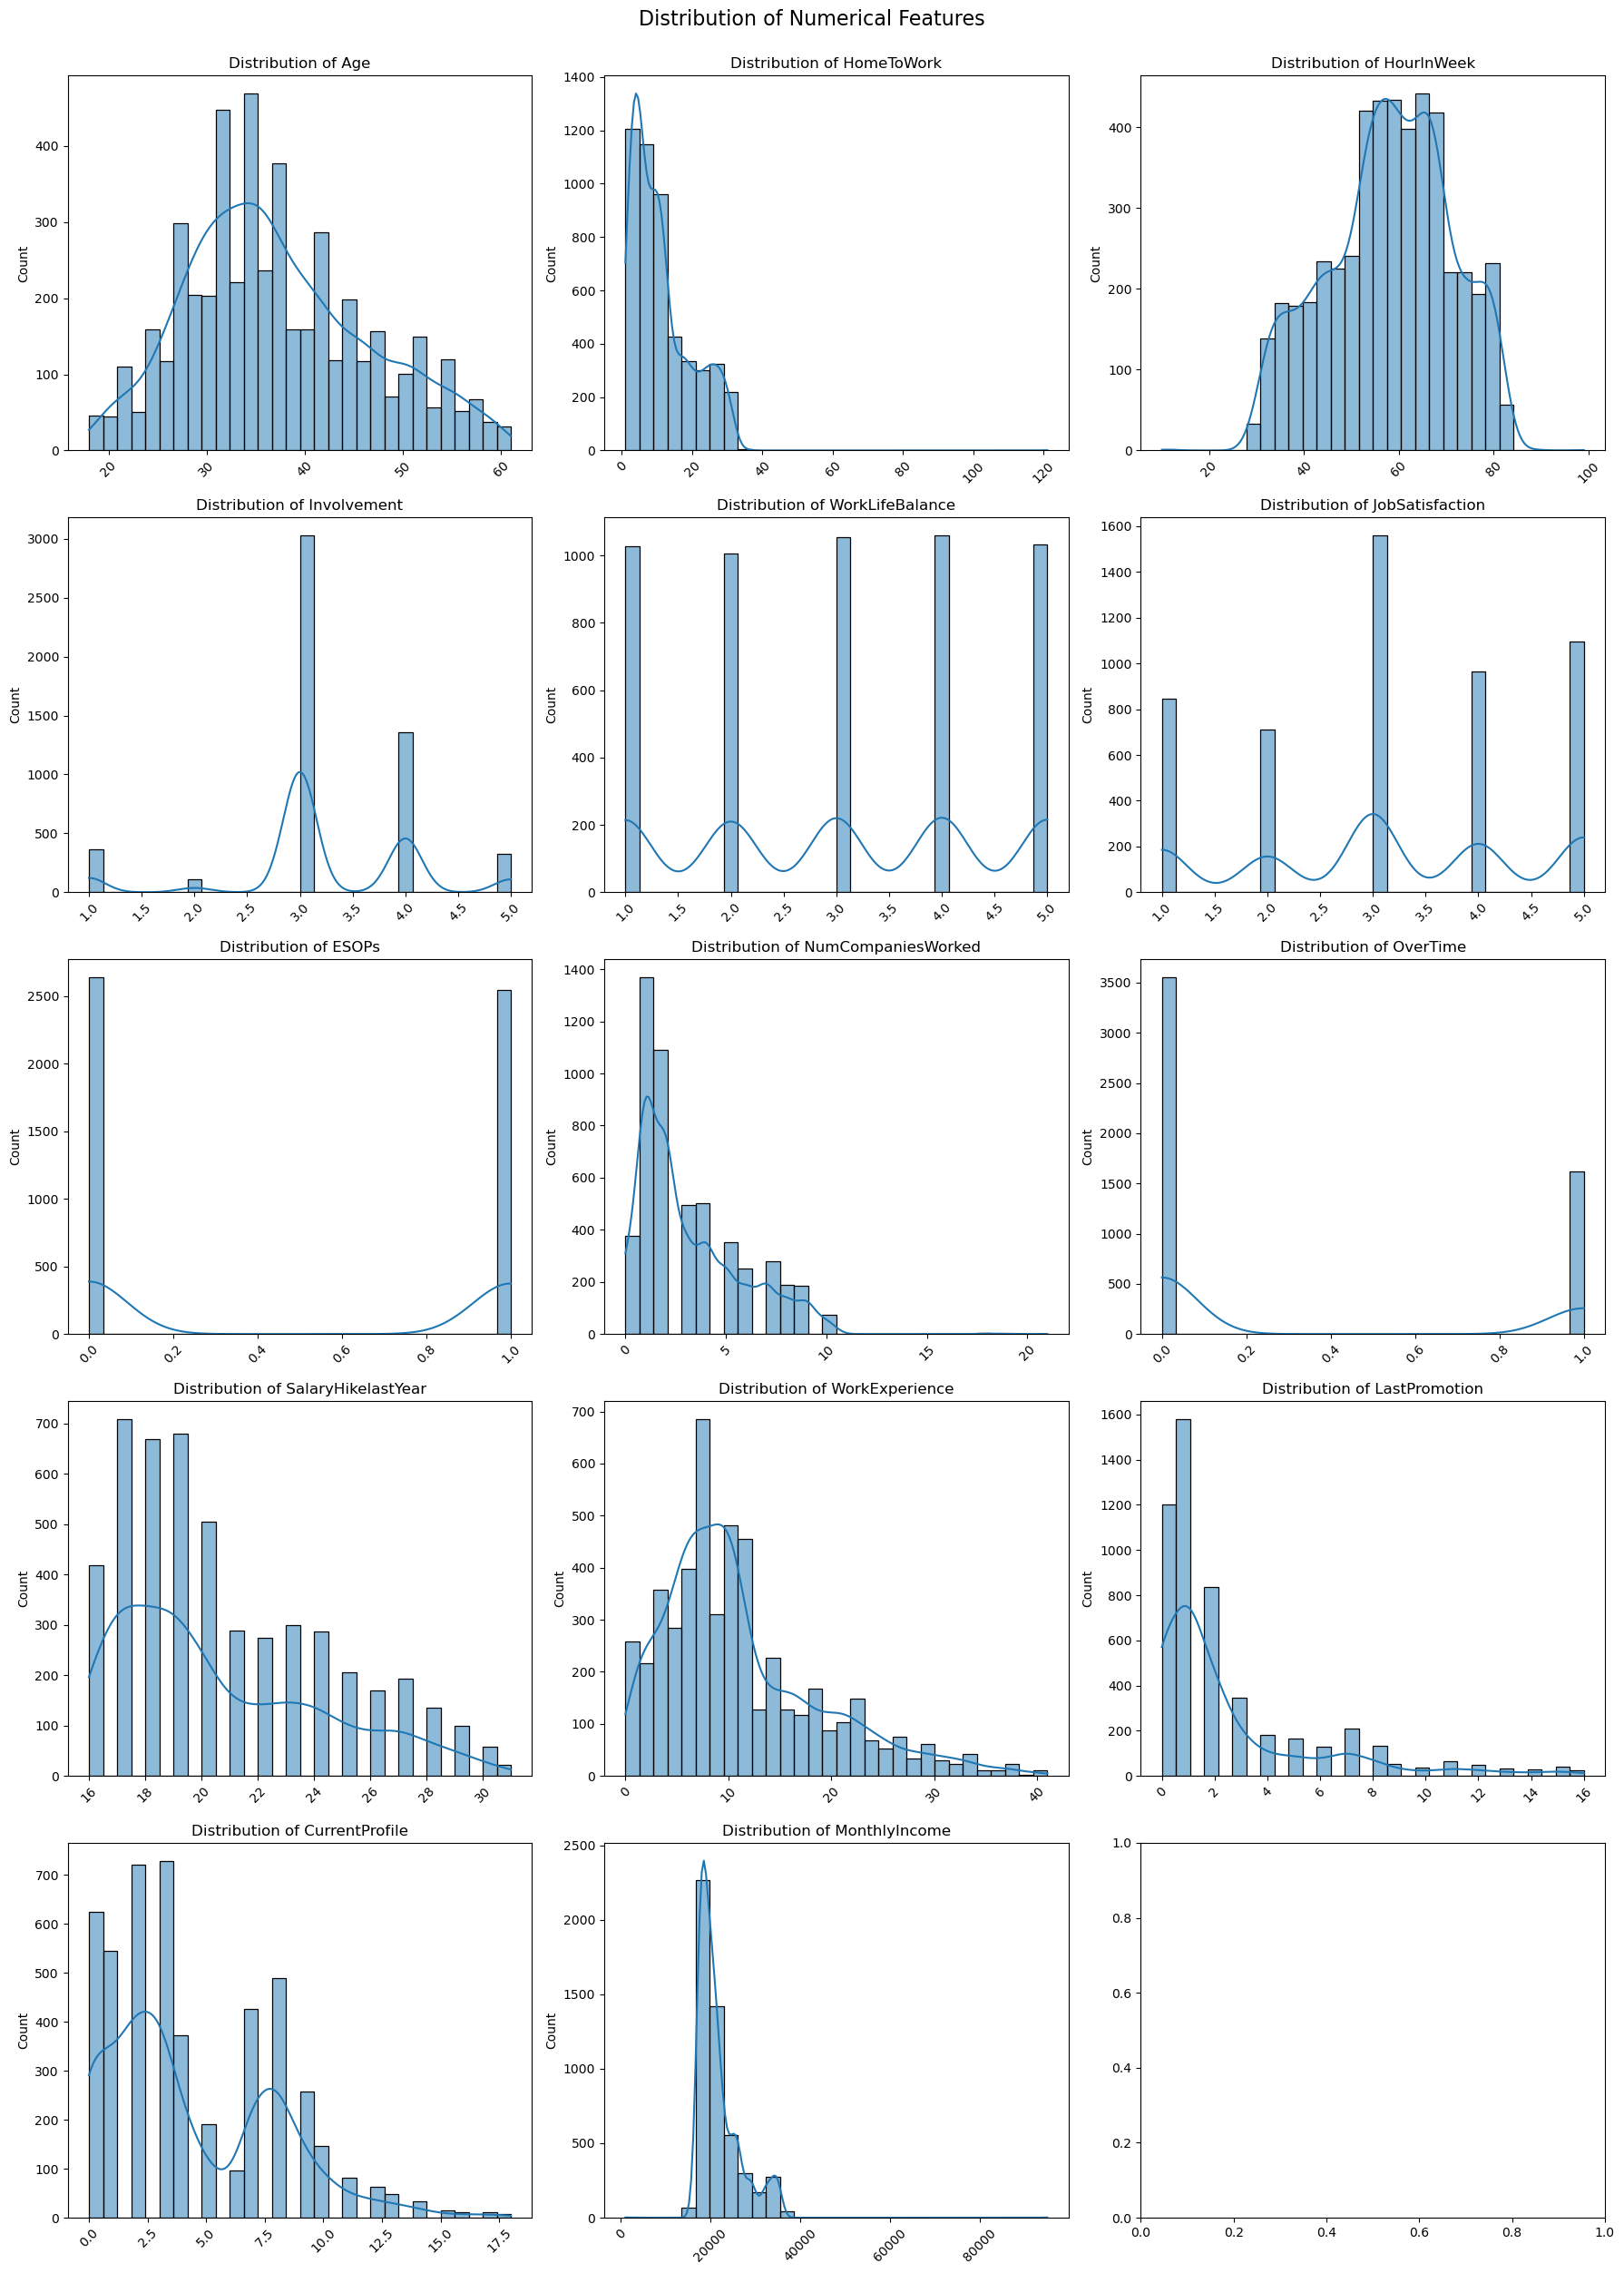

In [574]:
row = np.ceil(len(num_cols) / 3).astype(int)
col = 3

fig, axes = plt.subplots(row, col, figsize=(18, 5*row))
fig.suptitle('Distribution of Numerical Features', fontsize=16, y=1)
axes = axes.flatten()

for i, col_name in enumerate(num_cols):
    ax = axes[i]
    sns.histplot(train_df[col_name], bins=30,kde=True, ax=ax)
    ax.set_title(f'Distribution of {col_name}')
    ax.tick_params(axis='x', rotation=45)
    ax.set_xlabel('')
    ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

In [575]:
skewed_cols = train_df[num_cols].skew()[train_df[num_cols].skew() > 1].index.tolist()
print("Skewed Numerical Columns:\n", skewed_cols)


Skewed Numerical Columns:
 ['HomeToWork', 'NumCompaniesWorked', 'WorkExperience', 'LastPromotion', 'MonthlyIncome']


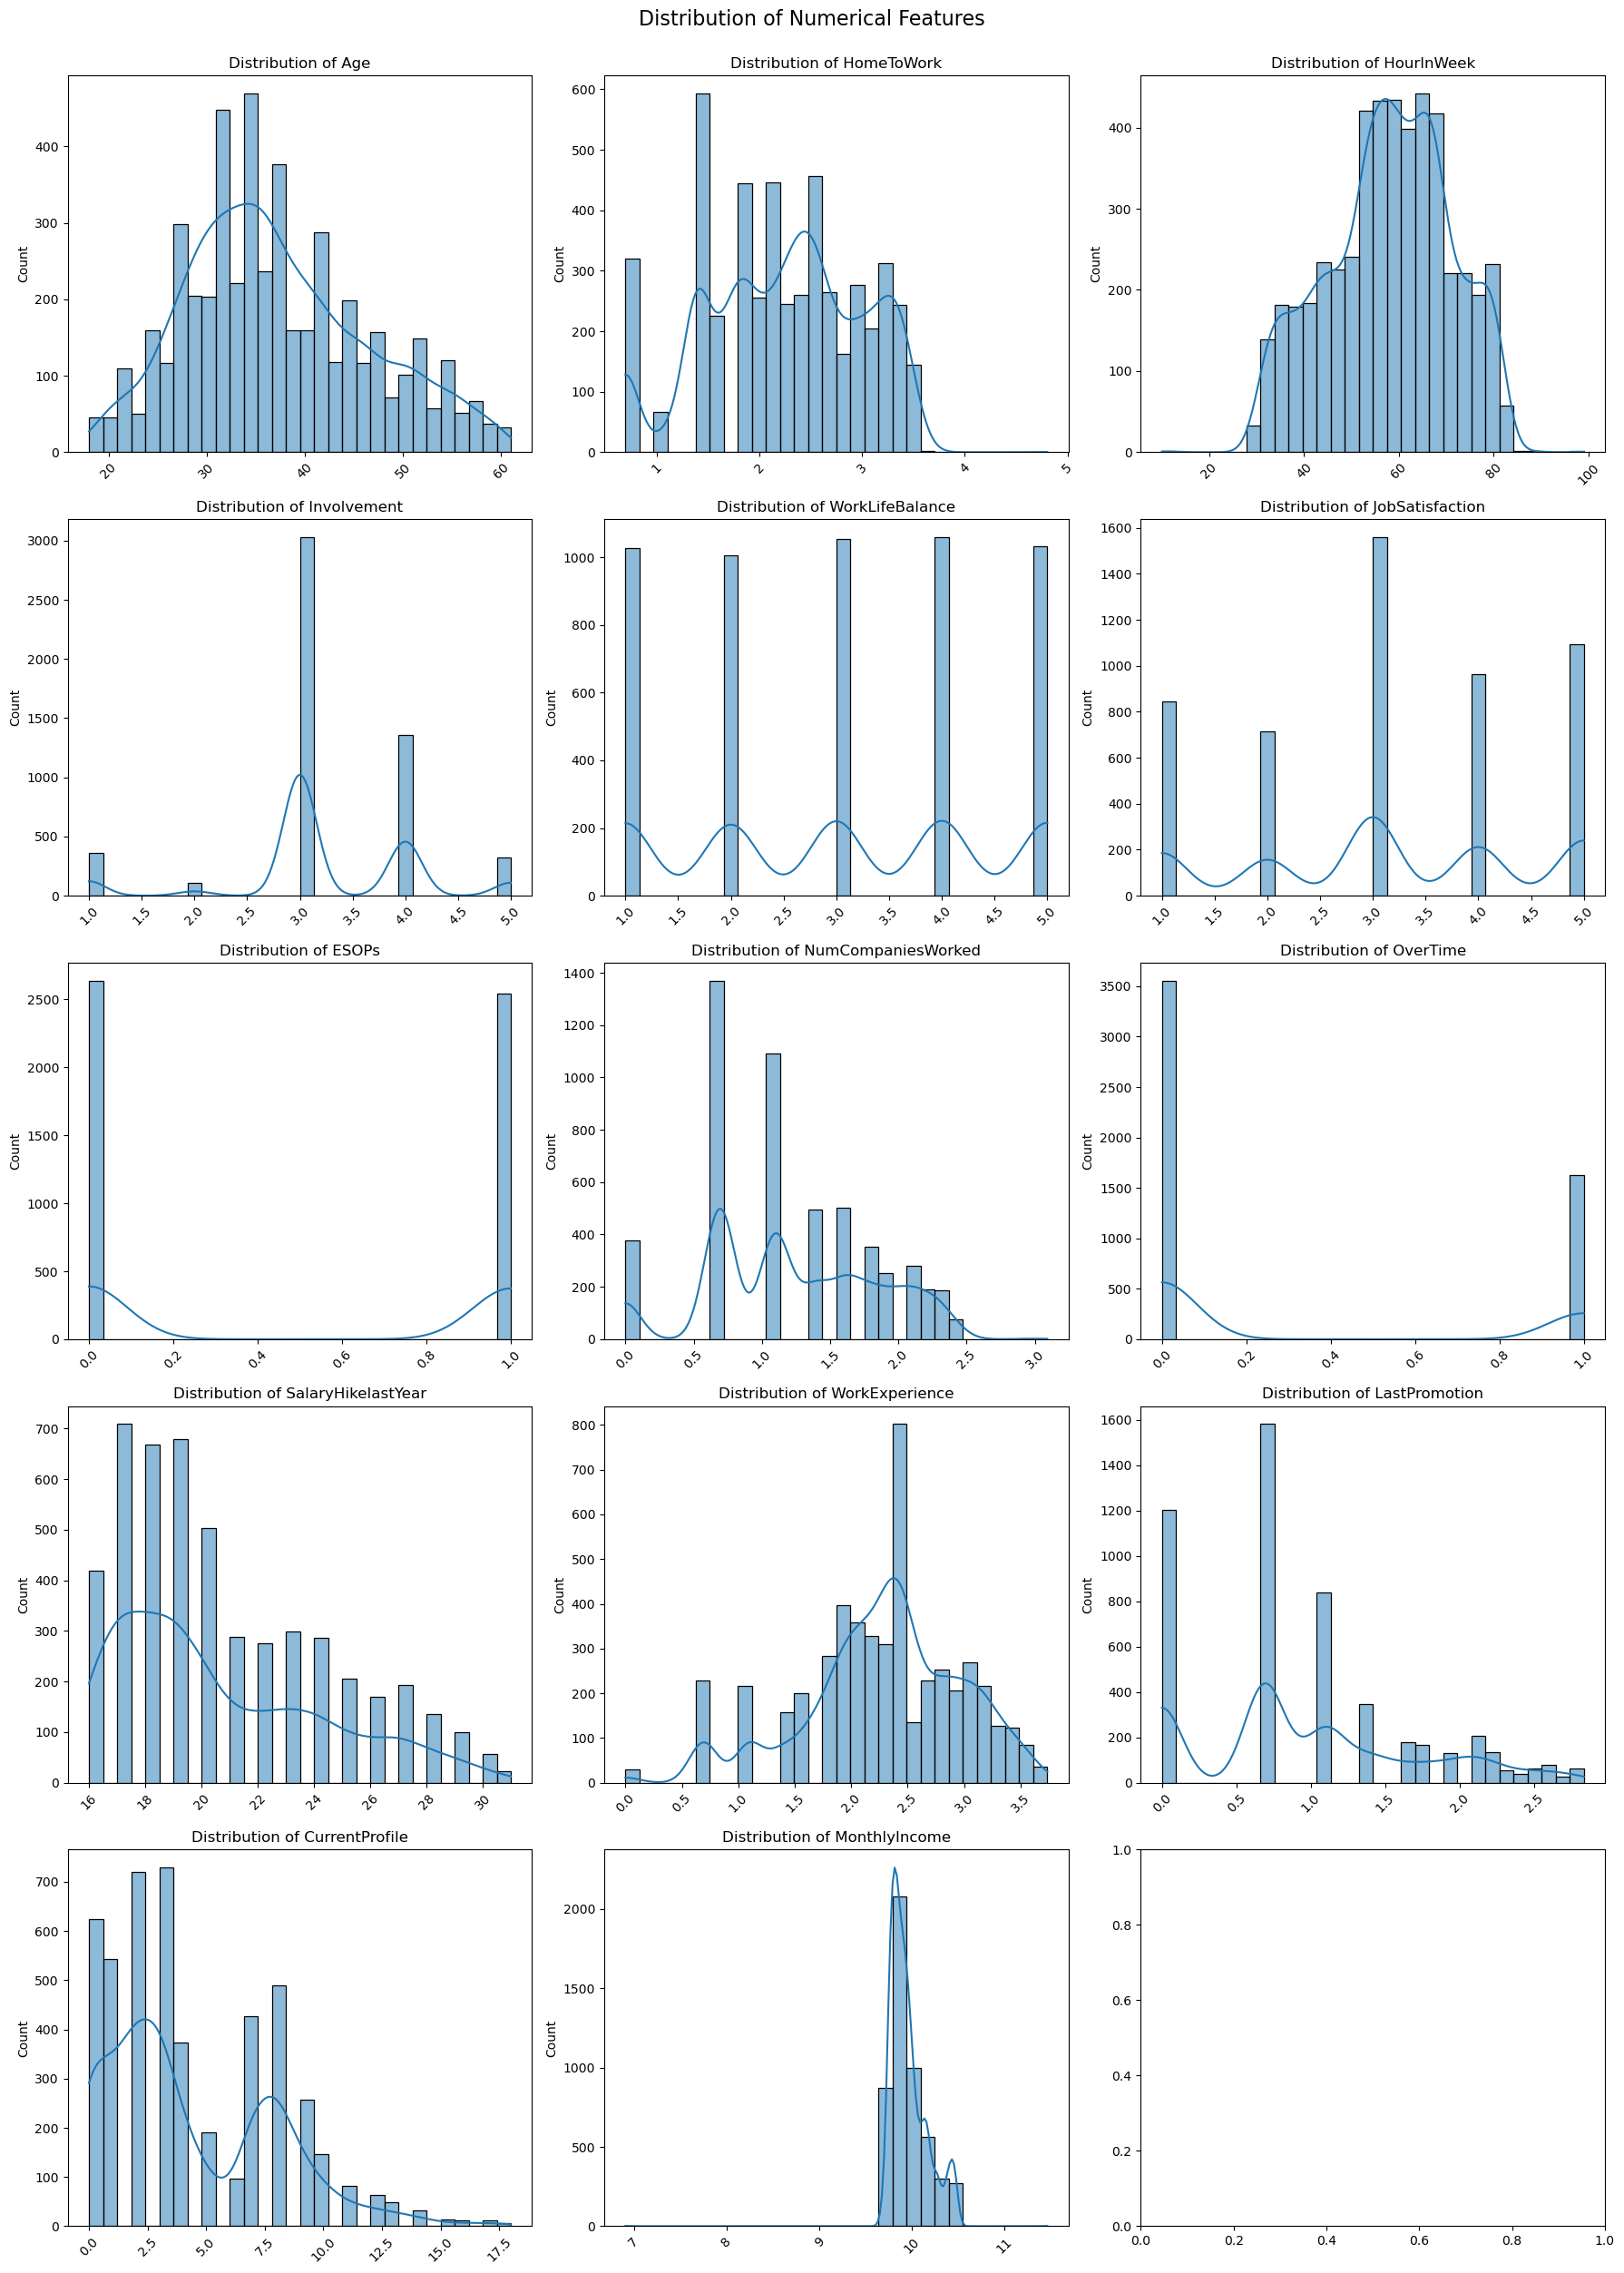

In [576]:
train_df_copy = train_df.copy()
train_df_copy[skewed_cols] = np.log1p(train_df_copy[skewed_cols])
row = np.ceil(len(num_cols) / 3).astype(int)
col = 3

fig, axes = plt.subplots(row, col, figsize=(18, 5*row))
fig.suptitle('Distribution of Numerical Features', fontsize=16, y=1)
axes = axes.flatten()

for i, col_name in enumerate(num_cols):
    ax = axes[i]
    sns.histplot(train_df_copy[col_name], bins=30,kde=True, ax=ax)
    ax.set_title(f'Distribution of {col_name}')
    ax.tick_params(axis='x', rotation=45)
    ax.set_xlabel('')
    ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

In [577]:
train_df['Attrition'].value_counts()

Attrition
0.0    3735
1.0    1445
Name: count, dtype: int64

<Axes: xlabel='Attrition', ylabel='count'>

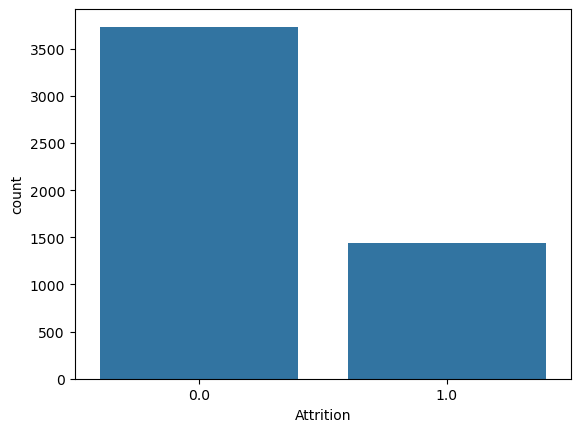

In [578]:
sns.countplot(x='Attrition', data=train_df)

# 3. Data Preprocessing

In [579]:
class InteractionFeatures(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        X['Income_per_Experience'] = X['MonthlyIncome'] / (X['WorkExperience'] + 1)
        X['Income_per_Age'] = X['MonthlyIncome'] / (X['Age'] + 1)
        X['Experience_per_Age'] = X['WorkExperience'] / (X['Age'] + 1)

        return X

In [580]:
class BinningFeatures(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        X['Age_Group'] = pd.cut(X['Age'], bins=[18, 30, 40, 50, 60]).astype(str)
        X['Income_Group'] = pd.qcut(X['MonthlyIncome'], q=4, duplicates='drop').astype(str)

        return X

In [581]:
class EfficiencyFeatures(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        X['WorkEfficiency'] = X['MonthlyIncome'] / (X['HomeToWork'] + 1)

        return X

In [582]:
class FrequencyEncoding(BaseEstimator, TransformerMixin):
    def __init__(self, cols):
        self.cols = cols
        self.freq_maps = {}

    def fit(self, X, y=None):
        for col in self.cols:
            self.freq_maps[col] = X[col].value_counts().to_dict()
        return self

    def transform(self, X):
        X = X.copy()
        for col in self.cols:
            X[col + '_freq'] = X[col].map(self.freq_maps[col])
        return X

In [583]:
class RiskFeature(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        X['High_Risk_Employee'] = (
            (X['OverTime'] == 'Yes') &
            (X['WorkLifeBalance'] <= 2)
        ).astype(int)

        return X

In [584]:
# function to change categorical values to more meaningful ones

class CategoryCleaner(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        # Fix Gender
        if 'Gender' in X.columns:
            X['Gender'] = X['Gender'].replace({
                'F': 'Female',
                'M': 'Male'
            })

        # Fix MaritalStatus
        if 'MaritalStatus' in X.columns:
            X['MaritalStatus'] = X['MaritalStatus'].replace({
                'M': 'Married'
            })

        return X

In [585]:
# function to log transform skewed features

class SkewnessTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, skewed_cols):
        self.skewed_cols = skewed_cols

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        for col in self.skewed_cols:
            X[col] = np.log1p(X[col])
        return X

In [586]:
feature_engineering = Pipeline([
    ('interaction', InteractionFeatures()),
    # ('binning', BinningFeatures()),
    ('efficiency', EfficiencyFeatures()),
    ('frequency', FrequencyEncoding(cols=['CurrentProfile'])),
    ('risk', RiskFeature())
])

In [587]:
feature_engineering.fit(X_train, y_train)
X_train_fe = feature_engineering.transform(X_train)
print(X_train_fe.columns)
display(X_train_fe.head())

Index(['Age', 'TravelProfile', 'Department', 'HomeToWork', 'EducationField',
       'Gender', 'HourlnWeek', 'Involvement', 'WorkLifeBalance', 'Designation',
       'JobSatisfaction', 'ESOPs', 'NumCompaniesWorked', 'OverTime',
       'SalaryHikelastYear', 'WorkExperience', 'LastPromotion',
       'CurrentProfile', 'MaritalStatus', 'MonthlyIncome',
       'Income_per_Experience', 'Income_per_Age', 'Experience_per_Age',
       'WorkEfficiency', 'CurrentProfile_freq', 'High_Risk_Employee'],
      dtype='object')


,Age,TravelProfile,Department,HomeToWork,EducationField,Gender,HourlnWeek,Involvement,WorkLifeBalance,Designation,...,LastPromotion,CurrentProfile,MaritalStatus,MonthlyIncome,Income_per_Experience,Income_per_Age,Experience_per_Age,WorkEfficiency,CurrentProfile_freq,High_Risk_Employee
1920,28.0,Yes,Analytics,NaN,Statistics,Male,39.0,4.0,1.0,Executive,...,0.0,2.0,M,17703.0,4425.750000,610.448276,0.103448,NaN,668.0,0
4851,51.0,Rarely,Sales,11.0,Marketing Diploma,Male,56.0,3.0,1.0,Executive,...,3.0,3.0,Divorsed,19875.0,3312.500000,382.211538,0.096154,1656.250000,645.0,0
4376,31.0,Rarely,Analytics,10.0,Statistics,Male,33.0,3.0,2.0,Senior Manager,...,0.0,8.0,Married,NaN,NaN,NaN,0.406250,NaN,435.0,0
5050,31.0,Yes,Analytics,21.0,Statistics,Male,66.0,3.0,1.0,Senior Manager,...,0.0,0.0,Divorsed,24824.0,1909.538462,775.750000,0.375000,1128.363636,566.0,0
2004,27.0,Rarely,Analytics,9.0,Statistics,Female,73.0,3.0,1.0,Executive,...,1.0,3.0,M,18659.0,3731.800000,666.392857,0.142857,1865.900000,645.0,0


In [588]:
num_cols = X_train_fe.select_dtypes(exclude=['object']).columns.tolist()
cat_cols = X_train_fe.select_dtypes(include=['object']).columns.tolist()
skewed_cols = X_train_fe[num_cols].skew()[X_train_fe[num_cols].skew() > 1].index.tolist()

num_cols, cat_cols, skewed_cols

(['Age',
  'HomeToWork',
  'HourlnWeek',
  'Involvement',
  'WorkLifeBalance',
  'JobSatisfaction',
  'ESOPs',
  'NumCompaniesWorked',
  'OverTime',
  'SalaryHikelastYear',
  'WorkExperience',
  'LastPromotion',
  'CurrentProfile',
  'MonthlyIncome',
  'Income_per_Experience',
  'Income_per_Age',
  'Experience_per_Age',
  'WorkEfficiency',
  'CurrentProfile_freq',
  'High_Risk_Employee'],
 ['TravelProfile',
  'Department',
  'EducationField',
  'Gender',
  'Designation',
  'MaritalStatus'],
 ['NumCompaniesWorked',
  'WorkExperience',
  'LastPromotion',
  'MonthlyIncome',
  'Income_per_Experience',
  'WorkEfficiency'])

In [589]:
# numerical pipeline with imputation, skewness transformation, and scaling

num_pipeline = Pipeline([
    ('skew', SkewnessTransformer(skewed_cols=skewed_cols)),
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [590]:
# categorical pipeline with imputation and one-hot encoding

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [591]:
# combine pipelines into a column transformer

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
],
    remainder='passthrough'
)

In [592]:
# full pipeline

full_pipeline = Pipeline([
    ('category_cleaner', CategoryCleaner()),
    ('feature_engineering', feature_engineering),
    ('preprocessing', preprocessor),
    ('model', RandomForestClassifier(random_state=42))
])

In [593]:
param_dist = [

    # Random Forest
    {
        'model': [RandomForestClassifier(random_state=42)],
        'model__class_weight': [None, 'balanced', 'balanced_subsample'],
        'model__n_estimators': randint(300, 700),
        'model__max_depth': [None, 10, 20, 30, 40],
        'model__min_samples_split': randint(2, 10),
        'model__min_samples_leaf': randint(1, 5),
        'model__max_features': ['sqrt', 'log2', None]
    },

    # Logistic Regression
    {
        'model': [LogisticRegression(max_iter=3000, random_state=42)],
        'model__class_weight': [None, 'balanced'],
        'model__C': uniform(0.01, 10),
        'model__solver': ['lbfgs', 'liblinear']
    },

    # Gradient Boosting
    {
        'model': [GradientBoostingClassifier(random_state=42)],
        'model__n_estimators': randint(150, 400),
        'model__learning_rate': uniform(0.03, 0.12),
        'model__max_depth': randint(3, 7),
        'model__subsample': uniform(0.7, 0.3)
    },

    # Bagging
    {
        'model': [BaggingClassifier(random_state=42)],
        'model__n_estimators': randint(30, 150),
        'model__max_samples': uniform(0.6, 0.4),
        'model__max_features': uniform(0.6, 0.4)
    },

    # XGBoost
    {
        'model': [XGBClassifier(
            eval_metric='logloss',
            random_state=42
        )],
        'model__n_estimators': randint(300, 700),
        'model__learning_rate': uniform(0.03, 0.12),
        'model__max_depth': randint(3, 10),
        'model__subsample': uniform(0.7, 0.3),
        'model__colsample_bytree': uniform(0.7, 0.3),
        'model__gamma': uniform(0, 3),
        'model__scale_pos_weight': [1, 2, 3, 5]
    },

    # LightGBM
    {
        'model': [LGBMClassifier(random_state=42, verbose=-1)],
        'model__class_weight': [None, 'balanced'],
        'model__n_estimators': randint(300, 700),
        'model__learning_rate': uniform(0.03, 0.12),
        'model__num_leaves': randint(20, 100),
        'model__max_depth': [-1, 10, 20, 30],
        'model__subsample': uniform(0.7, 0.3),
        'model__colsample_bytree': uniform(0.7, 0.3)
    }
]

In [594]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

In [595]:
random_search = RandomizedSearchCV(
    estimator=full_pipeline,
    param_distributions=param_dist,
    n_iter=30,                 # increase if time permits
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=0,
    random_state=42
)

In [596]:
random_search.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,param_distributions,"[{'model': [RandomForestC...ndom_state=42)], 'model__class_weight': [None, 'balanced', ...], 'model__max_depth': [None, 10, ...], 'model__max_features': ['sqrt', 'log2', ...], ...}, {'model': [LogisticRegre...ndom_state=42)], 'model__C': <scipy.stats....t 0x33eab9780>, 'model__class_weight': [None, 'balanced'], 'model__solver': ['lbfgs', 'liblinear']}, ...]"
,n_iter,30
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [597]:
print("Best Params:", random_search.best_params_)
print("Best Score:", random_search.best_score_)

Best Params: {'model': LGBMClassifier(random_state=42, verbose=-1), 'model__class_weight': 'balanced', 'model__colsample_bytree': np.float64(0.8640130838029838), 'model__learning_rate': np.float64(0.052182534663063246), 'model__max_depth': 20, 'model__n_estimators': 517, 'model__num_leaves': 63, 'model__subsample': np.float64(0.9818496824692566)}
Best Score: 0.9755469755469756


Total candidates tried: 30

Trials per model:


model_name
XGBClassifier                 8
LGBMClassifier                7
RandomForestClassifier        5
LogisticRegression            5
BaggingClassifier             3
GradientBoostingClassifier    2
Name: trials, dtype: int64


Top 5 configurations overall:


,rank_test_score,mean_test_score,std_test_score,model_name,params
10,1,0.975547,0.006059,LGBMClassifier,"{'model': LGBMClassifier(random_state=42, verb..."
5,2,0.974903,0.008681,LGBMClassifier,"{'model': LGBMClassifier(random_state=42, verb..."
16,3,0.974474,0.007746,LGBMClassifier,"{'model': LGBMClassifier(random_state=42, verb..."
25,4,0.974045,0.005906,LGBMClassifier,"{'model': LGBMClassifier(random_state=42, verb..."
11,5,0.973831,0.007056,LGBMClassifier,"{'model': LGBMClassifier(random_state=42, verb..."



Best score by model family:


,trials,best_score,avg_score
model_name,,,
LGBMClassifier,7,0.975547,0.974076
GradientBoostingClassifier,2,0.968897,0.968790
BaggingClassifier,3,0.967610,0.965179
XGBClassifier,8,0.966109,0.952783
RandomForestClassifier,5,0.965894,0.956199
LogisticRegression,5,0.809738,0.790734


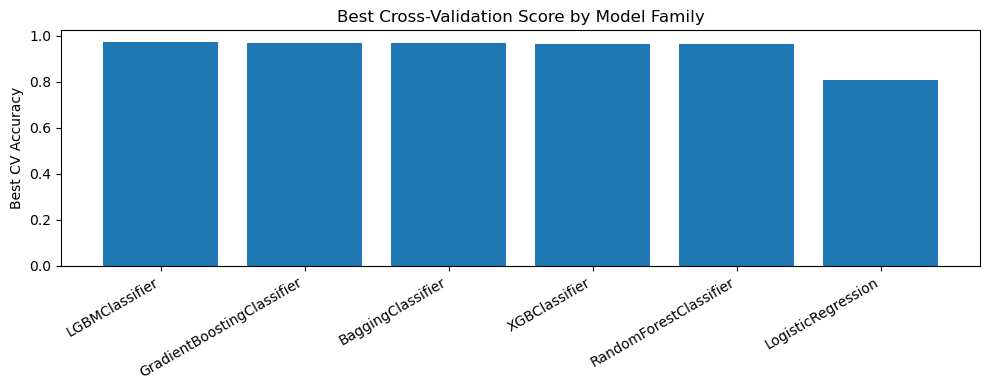

In [598]:
# Review all RandomizedSearchCV candidates and compare model families
results = pd.DataFrame(random_search.cv_results_)

# Extract readable model name from estimator object string
results['model_name'] = (
    results['param_model']
    .astype(str)
    .str.extract(r'^([A-Za-z_][A-Za-z0-9_]*)')[0]
    .fillna('UnknownModel')
)

print(f"Total candidates tried: {len(results)}")
print("\nTrials per model:")
display(results['model_name'].value_counts().rename('trials'))

print("\nTop 5 configurations overall:")
top_cols = ['rank_test_score', 'mean_test_score', 'std_test_score', 'model_name', 'params']
display(results[top_cols].sort_values(['rank_test_score', 'mean_test_score'], ascending=[True, False]).head(5))

print("\nBest score by model family:")
by_model = (
    results.groupby('model_name', dropna=False)['mean_test_score']
    .agg(trials='count', best_score='max', avg_score='mean')
    .sort_values('best_score', ascending=False)
)
display(by_model)

plt.figure(figsize=(10, 4))
plt.bar(by_model.index.astype(str), by_model['best_score'])
plt.xticks(rotation=30, ha='right')
plt.ylabel('Best CV Accuracy')
plt.title('Best Cross-Validation Score by Model Family')
plt.tight_layout()
plt.show()

In [599]:
y_pred = random_search.best_estimator_.predict(X_test)
y_probs = random_search.best_estimator_.predict_proba(X_test)[:, 1]

In [600]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_probs))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9845559845559846
Precision: 0.9657534246575342
Recall: 0.9791666666666666
F1 Score: 0.9724137931034482
ROC-AUC: 0.9996100713012478

Confusion Matrix:
 [[369   5]
 [  3 141]]

Classification Report:
               precision    recall  f1-score   support

         0.0       0.99      0.99      0.99       374
         1.0       0.97      0.98      0.97       144

    accuracy                           0.98       518
   macro avg       0.98      0.98      0.98       518
weighted avg       0.98      0.98      0.98       518



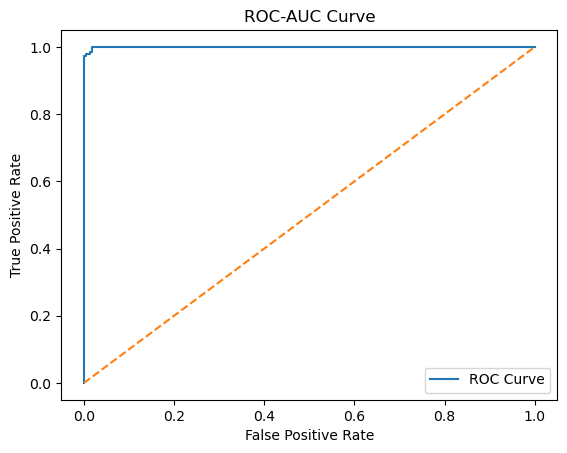

In [601]:
fpr, tpr, thresholds = roc_curve(y_test, y_probs)

plt.figure()
plt.plot(fpr, tpr, label="ROC Curve")
plt.plot([0, 1], [0, 1], linestyle="--")  # random line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curve")
plt.legend()
plt.show()

In [602]:
thresholds = np.arange(0.1, 0.9, 0.05)

results = []

for t in thresholds:
    y_pred = (y_probs > t).astype(int)
    
    results.append({
        'Threshold': t,
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred)
    })

import pandas as pd
threshold_df = pd.DataFrame(results)

display(threshold_df.sort_values(by='F1', ascending=False))

,Threshold,Precision,Recall,F1
11,0.65,0.986014,0.979167,0.982578
12,0.70,0.986014,0.979167,0.982578
13,0.75,0.986014,0.979167,0.982578
14,0.80,0.986014,0.979167,0.982578
9,0.55,0.979167,0.979167,0.979167
10,0.60,0.979167,0.979167,0.979167
15,0.85,0.985915,0.972222,0.979021
1,0.15,0.965986,0.986111,0.975945
2,0.20,0.965986,0.986111,0.975945
3,0.25,0.965753,0.979167,0.972414


In [603]:
best_t = threshold_df.sort_values(by='F1', ascending=False).iloc[0]['Threshold']
print("Best Threshold:", best_t)

Best Threshold: 0.6500000000000001


In [604]:
y_pred_opt = (y_probs > best_t).astype(int)

In [605]:
confusion_matrix(y_test, y_pred_opt)

array([[372,   2],
       [  3, 141]])

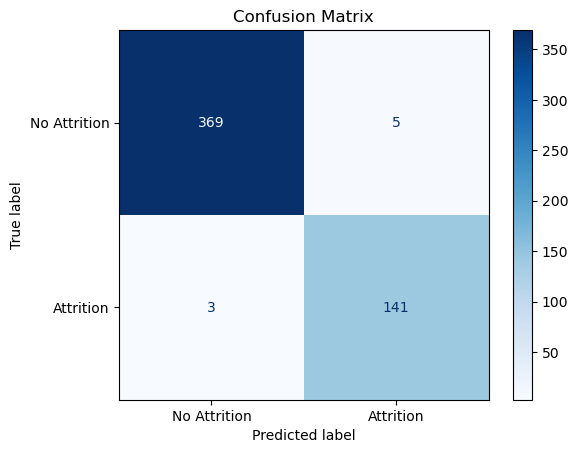

In [606]:
ConfusionMatrixDisplay.from_estimator(random_search.best_estimator_, X_test, y_test, display_labels=['No Attrition', 'Attrition'], cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

In [607]:
# predictions on the test set using GBC
test_features = test_df.drop(columns=['EmployeeID'])
test_predictions_gb = random_search.best_estimator_.predict(test_features)
y_pred_opt = (test_predictions_gb > best_t).astype(int)

# submission dataframe for GBC
submission_df_gb = pd.DataFrame({
    'EmployeeID': test_df['EmployeeID'],
    'Attrition': y_pred_opt
})

# Save the file for GBC
submission_file_path_gb = 'submission_3.csv'
submission_df_gb.to_csv(submission_file_path_gb, index=False)